In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tracker
import stats
import visualizer
import utils

import importlib

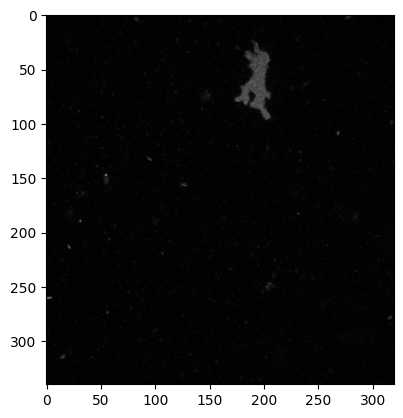

In [3]:
videofile = "ExampleVideos/amoebae.mp4"

# Visualize the input
cap = cv2.VideoCapture(videofile)

# Get the first frame
ret, frame = cap.read()

plt.imshow(frame)

In [4]:
# Because the video is so long, grab every 10th frame
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)
    for _ in range(9):
        cap.read()  # Skip the next 9 frames
cap.release()

np.array(frames).shape

(532, 340, 320, 3)

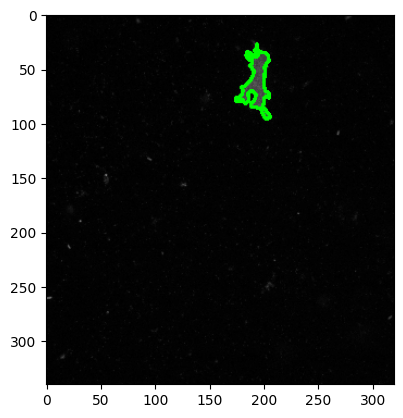

In [17]:
def getAmoebaeContours(frame, thresh=50, min_area=50):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    amoebae_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
    return amoebae_contours

# Visualize the contours
contour_img = frames[0].copy()
amoebae_contours = getAmoebaeContours(frames[0])
cv2.drawContours(contour_img, amoebae_contours, -1, (0, 255, 0), 2)
plt.imshow(contour_img)

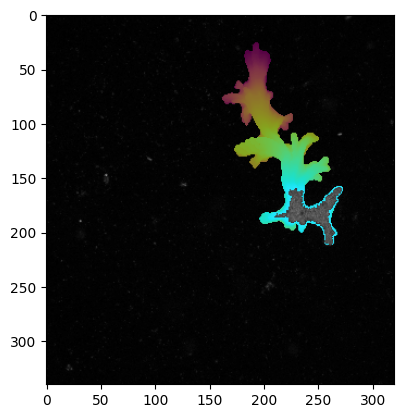

In [ ]:
# For each frame, get the contours and draw a time sequence of colors
final_frame = 370
canvas_image = frames[final_frame].copy()

# Use colormap to generate a range of colors
colormap = plt.cm.viridis

for i in range(final_frame):
    contour_img = frames[i].copy()
    amoebae_contours = getAmoebaeContours(contour_img,50,500)
    #color = (0, 255, 0)  # Green color for contours
    # Get RGB color from colormap and convert to BGR format for OpenCV
    rgb_color = colormap(i / final_frame)[:3]
    # Convert to 0-255 range and BGR format, ensuring Python integers
    color = (int(rgb_color[2] * 255), int(rgb_color[1] * 255), int(rgb_color[0] * 255))
    cv2.drawContours(canvas_image, amoebae_contours, -1, color, 2)

# Redetect contours on the final frame and draw the original amoebae on top
final_contours = getAmoebaeContours(frames[final_frame],50,500)
mask = np.zeros_like(canvas_image)
mask = cv2.drawContours(mask, final_contours, -1, (255, 255, 255), thickness=cv2.FILLED)
original_amoebae = cv2.bitwise_and(frames[final_frame], mask)
canvas_image[np.where(mask==255)] = original_amoebae[np.where(mask==255)]


plt.imshow(canvas_image)
plt.show()

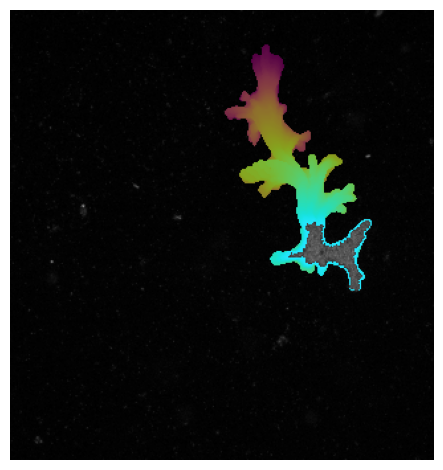

In [40]:
# Save figure with no axes and tight layout
plt.imshow(canvas_image)
plt.axis('off')
plt.tight_layout()
plt.savefig('amoebae_contours.png', bbox_inches='tight', pad_inches=0)

### Feed through the tracking pipeline

In [ ]:
importlib.reload(tracker)
importlib.reload(utils)

frames = utils.loadVideo(videofile,as_gray=True)
f = tracker.determineCentroids(frames)
t = tracker.trackCentroids(f)

print(t.head())

In [ ]:
importlib.reload(tracker)

compute_segments = True
if compute_segments:
    final = tracker.segmentCells(frames, t)
else:
    final = t

print(final.head())

In [ ]:
utils.saveDataFrame(final, videofile.split('.')[0] + '.csv')

### Feed through the statistics pipeline

In [ ]:
importlib.reload(stats)

final = stats.computeAllStats(final)

print(final.head())

In [ ]:
utils.saveDataFrame(final, videofile.split('.')[0] + '.csv')

### Use Visualizations

In [ ]:
importlib.reload(visualizer)

visualizer.runVisualization(videofile, final, visualization="segments")